In [28]:
# save tweets to output_got.csv
# input: keyword
## keyword = 'protestando'
## date = 12/31/2016 to 01/05/2017
##!python Exporter.py --querysearch "protest" --since 2019-02-25 --until 2019-02-26 --maxtweets 5000
##!python Exporter.py --querysearch "протеста" --since 2018-10-28 --until 2018-10-29 --maxtweets 5000
##!python Exporter.py --querysearch "protest" --since 2019-02-25 --until 2019-02-26 --maxtweets 5000
"""
raise Exception('stop')
Boris 'Nemtsov'


"""
from Exporter import main
protesting_russian = 'протестуя'
protesting_russian_root = 'протест'  ## this is the shortest particle
protes = 'протестовать'
protestovat = 'protestovat'

##fnameout = 'all_russian_terms_search_20190701_20190923.csv'


with open('russian_terms.txt') as f:
    terms_i = [(i,term.strip()) for i,term in enumerate(f)]
    ilast = 0
    for ii in range(4,len(terms_i),4):
        print (ilast, ii), "russian_term_all_%d.csv"
        query = ' '.join([t for i,t in terms_i if ilast <= i < ii])
        print query
        ilast = ii
fnameout = 'out.csv'
##raise Exception

terms = 'Акция протеста'
##terms = 'Следственный комитет Соболь Собянин'
##terms = 'августа авруста Автозак'
##terms = 'Каратели Космонавты Лоличанск Любовь'
##terms = 'августа июля июля августа'
##terms = 'августа or июля or июля or августа'
##terms = ' '.join()
print terms
main(['--querysearch',terms,'--since', 
              '2019-07-01', 
          '--until','2019-09-28',
          '--maxtweets',
          '1000000',
  '--output',fnameout])
        
print term


(0, 4) russian_term_all_%d.csv
августа июля июля августа
(4, 8) russian_term_all_%d.csv
авруста Автозак Акция оппозиции Акция протеста
(8, 12) russian_term_all_%d.csv
Арестованный Бандитизм бандиты в масках в масках
(12, 16) russian_term_all_%d.csv
В Москве задержали вилы брать Винтилово Власть дрогнула
(16, 20) russian_term_all_%d.csv
Все на Трубную выборы в Мосгордуму Группа риска дубинки
(20, 24) russian_term_all_%d.csv
Жандармы жестоко и беспощадно жуликов и воров жёстко задерживают
(24, 28) russian_term_all_%d.csv
Забег против произвола Заявка оппозиции Избивают иски на участников
(28, 32) russian_term_all_%d.csv
Каратели Космонавты Лоличанск Любовь Соболь
(32, 36) russian_term_all_%d.csv
Любочка Соболь Массовое мероприятие Массовые беспорядки МВД
(36, 40) russian_term_all_%d.csv
Менты мирный митинг Митинг На Сахарова
(40, 44) russian_term_all_%d.csv
Навальный наводить порядок нападении на полицейских начали избивать
(44, 48) russian_term_all_%d.csv
Не согласовали Независимые канд

In [ ]:
# Next, import the csv file into google spreadsheets.  (click and drag the csv to "My Drive" then open it)
# create a new column after 'text' called 'english' and input the formulat =GOOGLETRANSLATE('text' field)
# after all the translations are done, choose Download as >> csv

In [1]:
# lookup the location of the df['english'] translated tweet field - takes about 1 sec per location
# todo: rewrite this as async/multiprocessing but the shelve is not async-compliant, so should sync() sequentially

# IMPORTANT: run this cell multiple times until there's no printout.  Each time it shelves its state
# so we can continue running this cell to get incremental results

# Scan in csv having 'english' translated column from 'text' (e.g. spanish)
import pandas as pd
csvname = 'russia_protest_jul_sep_2019_translated.csv'
shelf_name = csvname+'.shelf'
df = pd.read_csv(csvname)

from bulk_location import locations
import shelve

d = shelve.open(shelf_name)

from googlemaps.exceptions import TransportError
N = len(df)
for i,text in enumerate(df['english']):
    key = str(i)
    if key in d:
        continue
    try:
        print text
        locs = locations(text, ntop=3)
    except TransportError:
        continue
    d[key] = locs
    print i, N
    d.sync()

print len(d.keys()), len(df)
print 'done'
d.close()

26267 26267
done


In [2]:
# put location results into df['loc']
english_locs = shelve.open(shelf_name)
keys = [k for k in sorted([int(k) for k in sorted(english_locs.keys())])]  # keys must be strings; convert back to int & sort
eng_text = [english_locs[str(k)] for k in keys]
assert len(eng_text) == len(df)
df['loc'] = eng_text

In [3]:
# convert datetime to native pandas
df['date'] = pd.to_datetime(df['date'])

In [4]:
## get a lat, lon from the places information
def resolve_location_first_latlon(row):
    if not row:
        return None,None
    for element in row:
        if element[2] != '' and element[3] != '':
            ##print element
            return element[4],float(element[2]), float(element[3])
    return None,None

In [5]:
# Export Russia-related places more specific than country
russia_locations = [bool(p and p != [] and u'countrypolitical' not in p[0] and 'Russia' in p[0][4]) for p in df['loc']]

fname = 'russia_protest_jul_sep_2019_translated_locations.csv'

print any(russia_locations)
print sum(russia_locations)
places, lats,lons = zip(*[resolve_location_first_latlon(d) for d in df[russia_locations]['loc']])
print len(lats), len(lons)
# fill in default lat/lon/place name for non-MX results (won't show up in output)
df['lat'] = 0.
df['lon'] = 0.
df['place name'] = None
# break out (lat, lon, place name) into separate columns
df.loc[russia_locations, 'lat'] = lats
df.loc[russia_locations, 'lon'] = lons
df.loc[russia_locations, 'place name'] = places
# inspection of df - max date
min(df['date']), max(df['date'])

df[russia_locations].to_csv(fname, header=True, index=False, encoding='utf-8')

True
2327
2327 2327


In [6]:
# duplicates?
print len(set(df[russia_locations]['english']))
# 1862 unique 
print sum(russia_locations)
## 2327 Russia tweets with location, 1862 of them are unique tweets
russia_locations_with_country = [bool(p and p != [] and 'Russia' in p[0][4]) for p in df['loc']]
# 3508 Russia (inc. those specific to country)
print sum(russia_locations_with_country) 

1862
2327
3508


In [55]:
!sudo pip install pycountry

DEPRECATION: Python 2.7 will reach the end of its life on January 1st, 2020. Please upgrade your Python as Python 2.7 won't be maintained after that date. A future version of pip will drop support for Python 2.7.
Looking in indexes: https://pypi.org/simple, http://pypi.arable.cloud:6543/simple
You should consider upgrading via the 'pip install --upgrade pip' command.


In [7]:
import pycountry
all_countries = [c.name.lower() for c in pycountry.countries]
[ac for ac in all_countries if 'ussia' in ac]
all_countries.remove('russian federation')
all_countries += ['russia']

In [8]:
# calculate country attribution to overall tweet amounts: 3.5K russia, 1.1K US, 1.0K ukraine
from collections import Counter
c = Counter()
for p in df['loc']:
    if p and p != []:
        x = p[0][4].lower()
        s = [cc.strip() for cc in x.split(',')]
        overlap = set(s) & set(all_countries)
        if overlap == set():
            pass
        else:
            c.update(overlap)
print c.most_common()

[(u'russia', 3508), (u'united states', 1097), (u'ukraine', 1031), (u'hong kong', 314), (u'france', 169), (u'japan', 152), (u'bulgaria', 144), (u'china', 106), (u'georgia', 102), (u'germany', 67), (u'serbia', 66), (u'armenia', 45), (u'italy', 37), (u'lithuania', 37), (u'latvia', 33), (u'belarus', 30), (u'united kingdom', 29), (u'north macedonia', 28), (u'canada', 25), (u'israel', 24), (u'kazakhstan', 24), (u'estonia', 23), (u'czechia', 23), (u'romania', 19), (u'india', 18), (u'turkey', 17), (u'spain', 17), (u'greece', 16), (u'poland', 15), (u'egypt', 13), (u'bosnia and herzegovina', 12), (u'switzerland', 12), (u'brazil', 11), (u'mexico', 9), (u'hungary', 9), (u'netherlands', 8), (u'azerbaijan', 7), (u'australia', 6), (u'puerto rico', 6), (u'kyrgyzstan', 6), (u'sudan', 4), (u'luxembourg', 4), (u'norway', 4), (u'belgium', 4), (u'lebanon', 4), (u'denmark', 4), (u'jordan', 3), (u'austria', 3), (u'ethiopia', 3), (u'qatar', 3), (u'zimbabwe', 3), (u'slovakia', 3), (u'albania', 3), (u'cuba', 3)

In [9]:
%matplotlib inline

import matplotlib
import numpy as np
import matplotlib.pyplot as plt

[(u'russia', 3508), (u'united states', 1097), (u'ukraine', 1031), (u'hong kong', 314), (u'france', 169), (u'japan', 152), (u'bulgaria', 144), (u'china', 106), (u'georgia', 102), (u'germany', 67), (u'serbia', 66), (u'armenia', 45), (u'italy', 37), (u'lithuania', 37), (u'latvia', 33), (u'belarus', 30), (u'united kingdom', 29), (u'north macedonia', 28), (u'canada', 25), (u'israel', 24), (u'kazakhstan', 24), (u'estonia', 23), (u'czechia', 23), (u'romania', 19), (u'india', 18), (u'turkey', 17), (u'spain', 17), (u'greece', 16), (u'poland', 15), (u'egypt', 13), (u'bosnia and herzegovina', 12), (u'switzerland', 12), (u'brazil', 11), (u'mexico', 9), (u'hungary', 9), (u'netherlands', 8), (u'azerbaijan', 7), (u'australia', 6), (u'puerto rico', 6), (u'kyrgyzstan', 6), (u'sudan', 4), (u'luxembourg', 4), (u'norway', 4), (u'belgium', 4), (u'lebanon', 4), (u'denmark', 4), (u'jordan', 3), (u'austria', 3), (u'ethiopia', 3), (u'qatar', 3), (u'zimbabwe', 3), (u'slovakia', 3), (u'albania', 3), (u'cuba', 3)

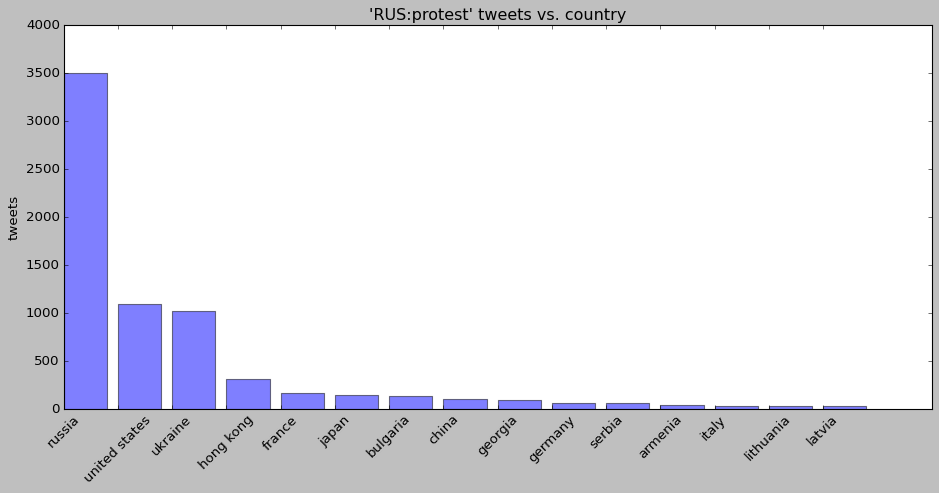

In [10]:
import matplotlib.pyplot as plt; plt.rcdefaults()
import numpy as np
import matplotlib.pyplot as plt

objects, performance = zip(*c.most_common()[:15])
print c.most_common()
##objects = ('Python', 'C++', 'Java', 'Perl', 'Scala', 'Lisp')
y_pos = np.arange(len(objects))
##performance = [10,8,6,4,2,1]

# Get current size
fig_size = plt.rcParams["figure.figsize"]
 
# Prints: [8.0, 6.0]
print "Current size:", fig_size
 
# Set figure width to 12 and height to 9
fig_size[0] = 14
fig_size[1] = 6
plt.rcParams["figure.figsize"] = fig_size

plt.bar(y_pos, performance, alpha=0.5)
plt.xticks(y_pos, objects,size=12)
plt.xticks(rotation=45)
plt.ylabel('tweets')
plt.title("'RUS:protest' tweets vs. country")
plt.show()

In [104]:
pd.set_option('display.max_colwidth', -1)

In [250]:
import geopandas

mask = (df_target['date'] > '2019-7-01') & (df_target['date'] <= '2019-7-07')
dft = df_target[mask]
subject = dft['english'].str.match('.*territory.*')
print 'tweets with territory-related protests', sum(subject)
dft[subject]

tweets with territory-related protests 23


,username,date,retweets,favorites,text,english,geo,mentions,hashtags,id,permalink,loc,lat,lon,place name
25361,zibo1668,2019-07-05 05:19:00,0,0,МИД России заявил протест Токио за обозначение юга Курил японской территорией https:// tass.ru/politika/66309 39?utm_referrer=https:%2F%2Fzen.yandex.com …,Russian Foreign Ministry said the designation for the southern Kurils protest Tokyo Japanese territory https: // tass.ru/politika/66309 39 utm_referrer = https:?% 2F% 2Fzen.yandex.com ...,NaN,NaN,NaN,1.147072e+18,https://twitter.com/zibo1668/status/1147072399701094400,"[[Kurils, GPE, 47.1543981, 150.9705378, Kuril Islands, Sakhalin Oblast, Russia, archipelagonatural_featureestablishment], [Tokyo, GPE, 35.6761919, 139.6503106, Tokyo, Japan, administrative_area_level_1political]]",47.154398,150.970538,"Kuril Islands, Sakhalin Oblast, Russia"
25382,62yakovlev,2019-07-05 02:28:00,0,0,МИД России заявил протест Токио за обозначение юга Курил японской территорией https:// tass.ru/politika/66309 39?utm_referrer=https:%2F%2Fzen.yandex.com%2F%3Ffrom%3Dspecial …,Russian Foreign Ministry said the designation for the southern Kurils protest Tokyo Japanese territory https: // tass.ru/politika/66309 39 utm_referrer = https:?% 2F% 2Fzen.yandex.com% 2F% 3Ffrom% 3Dspecial ...,NaN,NaN,NaN,1.147030e+18,https://twitter.com/62yakovlev/status/1147029502381449217,"[[Kurils, GPE, 47.1543981, 150.9705378, Kuril Islands, Sakhalin Oblast, Russia, archipelagonatural_featureestablishment], [Tokyo, GPE, 35.6761919, 139.6503106, Tokyo, Japan, administrative_area_level_1political]]",47.154398,150.970538,"Kuril Islands, Sakhalin Oblast, Russia"
25386,BesUran,2019-07-05 02:01:00,0,0,МИД России заявил протест Токио за обозначение юга Курил японской территорией https:// tass.ru/politika/66309 39 … - Да! Это вам не Крым!,Russian Foreign Ministry said the designation for the southern Kurils protest Tokyo Japanese territory https: // tass.ru/politika/66309 39 ... - Yes! This is not the Crimea!,NaN,NaN,NaN,1.147023e+18,https://twitter.com/BesUran/status/1147022576851378176,"[[Kurils, GPE, 47.1543981, 150.9705378, Kuril Islands, Sakhalin Oblast, Russia, archipelagonatural_featureestablishment], [Tokyo, GPE, 35.6761919, 139.6503106, Tokyo, Japan, administrative_area_level_1political]]",47.154398,150.970538,"Kuril Islands, Sakhalin Oblast, Russia"
25399,Svajkovskij49Br,2019-07-04 23:59:00,0,0,МИД России заявил протест Токио за обозначение юга Курил японской территорией https:// tass.ru/politika/66309 39?utm_referrer=https:%2F%2Fzen.yandex.com%2F%3Ffrom%3Dspecial …,Russian Foreign Ministry said the designation for the southern Kurils protest Tokyo Japanese territory https: // tass.ru/politika/66309 39 utm_referrer = https:?% 2F% 2Fzen.yandex.com% 2F% 3Ffrom% 3Dspecial ...,NaN,NaN,NaN,1.146992e+18,https://twitter.com/Svajkovskij49Br/status/1146991882171535361,"[[Kurils, GPE, 47.1543981, 150.9705378, Kuril Islands, Sakhalin Oblast, Russia, archipelagonatural_featureestablishment], [Tokyo, GPE, 35.6761919, 139.6503106, Tokyo, Japan, administrative_area_level_1political]]",47.154398,150.970538,"Kuril Islands, Sakhalin Oblast, Russia"
25424,InfoRUnews,2019-07-04 17:43:00,0,0,"Москва выразила Токио протест за обозначение Курил территорией Японии - Новости, события, факты, комментарии - https:// inforu.news/2019/07/04/mos kva-vyrazila-tokio-protest-za-oboznachenie-kuril-territoriej-yaponii/ … pic.twitter.com/B7AvzqOpTU","Moscow has expressed protest over Tokyo designation Kuriles Japanese territory - News, events, facts, comments - https: // inforu.news/2019/07/04/mos kva-vyrazila-tokio-protest-za-oboznachenie-kuril-territoriej-yaponii / ... pic.twitter.com/B7AvzqOpTU",NaN,NaN,NaN,1.146897e+18,https://twitter.com/InfoRUnews/status/1146897464647135232,"[[Moscow, GPE, 55.755826, 37.6172999, Moscow, Russia, localitypolitical], [Tokyo, GPE, 35.6761919, 139.6503106, Tokyo, Japan, administrative_area_level_1political]]",55.755826,37.617300,"Moscow, Russia"
25432,olegikww,2019-07-04 16:30:00

In [251]:
import geopandas

mask = (df_target['date'] > '2019-7-22') & (df_target['date'] <= '2019-7-30')
dft = df_target[mask]
subject = dft['english'].str.match('.*police.*')
print 'tweets with police-related protests', sum(subject)
dft[subject]

tweets with police-related protests 38


,username,date,retweets,favorites,text,english,geo,mentions,hashtags,id,permalink,loc,lat,lon,place name
18043,krasifiel,2019-07-29 20:20:00,0,1,"Протест 27 июля. Как похорошела Москва при Собянине. #митинг #мэрия #27июля 27 июля московская полиция задержала 1388 человек из почти 25 тысяч, вышедших на прогулку к мэрии.... https://www. youtube.com/attribution_li nk?a=4GXDkP8-_Iw&u=%2Fwatch%3Fv%3DQv7y5NZz5qc%26feature%3Dshare …","The protest on 27 July. As prettier when Moscow Sobyanin. # # City Hall rally # 27iyulya July 27 Moscow police detained 1388 people from nearly 25 000, published on a walk to City Hall .... https: // www. youtube.com/attribution_li nk? a = 4GXDkP8-_Iw & u =% 2Fwatch% 3Fv% 3DQv7y5NZz5qc% 26feature% 3Dshare ...",NaN,NaN,# # #27,1.155996e+18,https://twitter.com/krasifiel/status/1155996429569028096,"[[Moscow, GPE, 55.755826, 37.6172999, Moscow, Russia, localitypolitical], [City Hall, FAC, 40.360531, -74.6650521, 400 Witherspoon St, Princeton, NJ 08540, United States, local_government_officepoint_of_interestestablishment]]",55.755826,37.617300,"Moscow, Russia"
18092,ElvisMikle,2019-07-29 16:51:00,0,0,"Протест 27 июля. Как похорошела Москва при Собянине. #митинг #мэрия #27июля 27 июля московская полиция задержала 1388 человек из почти 25 тысяч, вышедших https:// youtu.be/Qv7y5NZz5qc с помощью @YouTube","The protest on 27 July. As prettier when Moscow Sobyanin. # # City Hall rally # 27iyulya July 27 Moscow police detained 1388 people out of nearly 25,000, published https: // youtu.be/Qv7y5NZz5qc via @YouTube",NaN,@YouTube,# # #27,1.155944e+18,https://twitter.com/ElvisMikle/status/1155943858653421568,"[[Moscow, GPE, 55.755826, 37.6172999, Moscow, Russia, localitypolitical], [youtu.be/Qv7y5NZz5qc, GPE, , , , , ], [City Hall, FAC, 40.360531, -74.6650521, 400 Witherspoon St, Princeton, NJ 08540, United States, local_government_officepoint_of_interestestablishment]]",55.755826,37.617300,"Moscow, Russia"
18159,DIMEROL,2019-07-29 14:00:00,0,0,"На заметку борцам за свободные выборы в России, страдающим от полицейского произвола и прочим пушным зверькам которых нежно выносят из помещения прямо на диване. Вот так поступает итальянская полиция в свободной европейской стране: #Митинг #Протест #27июля pic.twitter.com/iY3Y5MCXib","Note the fighters for free elections in Russia, suffering from police brutality and other fur-bearing animals which are gently taken out of the room right on the couch. That's Italian police comes in a free European country: # # The protest rally # 27iyulya pic.twitter.com/iY3Y5MCXib",NaN,NaN,# # #27,1.155901e+18,https://twitter.com/DIMEROL/status/1155900809839894528,"[[Russia, GPE, 61.52401, 105.318756, Russia, countrypolitical]]",0.000000,0.000000,None
18206,Nordik_51,2019-07-29 12:20:00,0,1,Протест в Москве не мог быть мирный априори ибо он был не согласован(посмотри на Ютубе действия полиции за рубежом при таком раскладе) перекрывали магистрали хотя даже либеральный бог Немцов говорил што этого делать категорически нельзя,"Protest in Moscow could not be peace priori because it had not been agreed (look on Youtube police action abroad in this situation) blocked the highway even though the liberal god Nemtsov spoke INTO to do this, you should not",NaN,NaN,NaN,1.155876e+18,https://twitter.com/Nordik_51/status/1155875709010817024,"[[Moscow, GPE, 55.755826, 37.6172999, Moscow, Russia, localitypolitical]]",55.755826,37.617300,"Moscow, Russia"
18389,pravda24,2019-07-29 07:01:00,0,0,"Московской оппозиции поможет армия Украины «Стихийный протест москвичей» оказался не стихийным, и, по данным полиции, не совсем московским. Среди участников беспорядков – много приезжих. Когда в « http:// ruspravda.info/Moskovskoy-opp ozitsii-pomozhet-armiya-Ukraini-36989.html … pic.twitter.com/HgqPS8FHif","Moscow opposition will ""spontaneous protest Muscovites"" Army of Ukraine was not natural, and, according to the police, it is not Moscow. Among the protestors - lots of visitors. When «http: // ruspravda.info/Moskovsk

In [189]:
# isolate only russia non-country locations
from collections import Counter
ix = []
for p in df['loc']:
    if p and p != []:
        x = p[0][4].lower()
        y = p[0][5].lower()
        if y == 'countrypolitical' and x == 'russia':
            ix += [False]
            continue
        s = [cc.strip() for cc in x.split(',')]
        overlap = set(s) & set(['russia'])
        if overlap != set():
            ix += [True]
            continue
        ix += [False]
    else:
        ix += [False]
print sum(ix)
s = set()
places = Counter()
for p in df[ix]['loc']:
    k = tuple(p[0][:4])
    places[k] += 1
places_common = [(p,mc) for p,mc in places.most_common() if mc > 10]
places_common

2327


[((u'Moscow', u'GPE', 55.755826, 37.6172999), 1512),
 ((u'Buryatia', u'GPE', 54.83311459999999, 112.406053), 122),
 ((u'Siberia', u'LOC', 61.01370970000001, 99.1966559), 85),
 ((u'MOSCOW', u'GPE', 55.755826, 37.6172999), 50),
 ((u'Kremlin', u'GPE', 55.7520233, 37.6174994), 47),
 ((u'Moscow City Duma', u'GPE', 55.7684009, 37.6118919), 32),
 ((u'Yekaterinburg', u'GPE', 56.83892609999999, 60.6057025), 30),
 ((u'Moscow City', u'GPE', 55.755826, 37.6172999), 28),
 ((u'the Kuril Islands', u'LOC', 47.15439809999999, 150.9705378), 22),
 ((u'Sakharov Avenue', u'FAC', 55.7705001, 37.6441108), 19),
 ((u'Ekaterinburg', u'GPE', 56.83892609999999, 60.6057025), 16),
 ((u'Kurils', u'GPE', 47.15439809999999, 150.9705378), 15),
 ((u'Novosibirsk', u'GPE', 55.00835259999999, 82.9357327), 15),
 ((u'Ulan Ude', u'FAC', 51.8238785, 107.607338), 14),
 ((u'Leningrad', u'GPE', 59.9342802, 30.3350986), 11)]

In [190]:
# now, for each region, quantify: daily tweet count per territory, violent words or negative sentiment

for x in df[ix][['loc','english']].iterrows():
    p,english = x[1]
    k = tuple(p[0][:4])
    print k, english

(u'Buryatia', u'GPE', 54.83311459999999, 112.406053) Putin replied HARD! Shaman and all activists detained. Protest in Buryatia ... https: // youtu.be/N5OfdAzIlRs via @YouTube
(u'Buryatia', u'GPE', 54.83311459999999, 112.406053) Putin replied HARD! Shaman and all activists detained. Protest in Buryatia ... https: // youtu.be/N5OfdAzIlRs via @YouTube
(u'Moscow', u'GPE', 55.755826, 37.6172999) Not only for the word. But simply for what went on protest. Vaughn is one thing that stands Moscow
(u'Moscow', u'GPE', 55.755826, 37.6172999) I read about the Moscow case. There's a guy who faces up to 5 years for what he is in his vidosikah talked about Mahatma Gandhi and Martin Luther King and the whole of such a flow, as a "non-violent protest." A MAIN MEM SITUATION KNOW WHAT?
(u'Buryatia', u'GPE', 54.83311459999999, 112.406053) Putin replied HARD! Shaman and all activists detained. Protest in Buryatia ... https: // youtu.be/N5OfdAzIlRs via @YouTube
(u'Buryatia', u'GPE', 54.83311459999999, 112.4

(u'Moscow', u'GPE', 55.755826, 37.6172999) The Kremlin first noticed a protest in Moscow / Whew for August 13, https: // youtu.be/hCbGENXmhvs using @YouTubehttps:? //Www.youtube.com/watch v = aOissNIvggw
(u'Kremlin', u'GPE', 55.7520233, 37.6174994) Kremlin protest Kindle? Law enforcers and the people / Consciousness Revolution https: // youtu.be/PqUiQB0R4xQ via @YouTube
(u'Moscow', u'GPE', 55.755826, 37.6172999) The Kremlin first noticed a protest in Moscow / Whew for August 13, https: // youtu.be/hCbGENXmhvs via @YouTube
(u'Moscow', u'GPE', 55.755826, 37.6172999) The Kremlin first noticed a protest in Moscow / Whew for August 13, https: // youtu.be/hCbGENXmhvs via @YouTube
(u'Siberia', u'LOC', 61.01370970000001, 99.1966559) China Embassy of the Russian Federation announced protest against the failure to extinguish the Chinese assets in Siberia.
(u'Moscow', u'GPE', 55.755826, 37.6172999) No need to drag in here to Moscow! It is better to read more comments on social networks, can be bo

(u'Moscow', u'GPE', 55.755826, 37.6172999) Moscow security forces arrested more than 800 protesters for fair elections # - https: // news-for.me/?p=183735 # # election protests Moscow # pic.twitter.com/ZT3L2RHPp8
(u'Moscow', u'GPE', 55.755826, 37.6172999) As one person canceled the protest in Moscow! Today, the revolution did not take place due to Denis Kosyakova! http: // mt-smi.ru/blog/439558439 10 / Kak-odin-chelovek-otmenil-protest-v-Moskve -Segodnya-revolyutsiy mid = 79C49253FDD1DC22924DC18DDD9FB64F & utm_campaign = transit & utm_source = main & utm_medium = page_66 & domain = mirtesen.ru & paid = 1 & pad =!? one …
(u'Moscow', u'GPE', 55.755826, 37.6172999) The Grandfather, fascism - is when in Moscow in the middle of the day punitive tourists batons pussy for what they were at the wrong time in the wrong place. And even if they were protesters, the protest was for free elections, and the answer received in the form of pizdyuley. That is fascism.
(u'Moscow', u'GPE', 55.755826, 37.

(u'Moscow', u'GPE', 55.755826, 37.6172999) Another thing is that the current student body is extremely weak. Expect them to deeds is not necessary. This fucking will take to the streets when their fathers. What I do not understand Moscow is the only city in the country fit for life, where they protest they have everything well
(u'Moscow', u'GPE', 55.755826, 37.6172999) - the biggest "unauthorized" protests in Moscow today - no one was afraid of arrests, threats - in peaceful protest intensified self-organization
(u'Chelyaba', u'GPE', 57.61017409999999, 56.24755769999999) Well, damn, some protest. When men with Chelyaba of any plant will go, it will be a protest. Well, from what to expect something hipsters
(u'Moscow', u'GPE', 55.755826, 37.6172999) A few words for the Moscow protest and liberal journalism ... everybody knows that cops are screws, so these bitches spices go and ask people, "Why have you come here," and how the expected result, those who are responsible ... https: // www

(u'Ryazan', u'GPE', 54.6095418, 39.7125857) Garbage protest came from not waiting near Ryazan there is another point of popular indignation. http: // vidsboku.com/articles/musor nyy-protest-prishel-otkuda-ne-zhdali ... pic.twitter.com/3kssHUpl0V
(u'Samara', u'GPE', 53.2415041, 50.2212463) "Clutching the egg"? You're getting education stray dogs in the community? You take off "is the same in Samara, at all 9 stations" or are no longer waiting for? And maybe it's time to go to the protest for the closure of the underground in Samara and close the station, just as "sooooo uzhOs life-threatening."
(u'Samara', u'GPE', 53.2415041, 50.2212463) Samara "Unlimited protest" came up against political arbitrariness http: // dlvr.it/R842vW pic.twitter.com/PpqGO2FVPa
(u'Yekaterinburg', u'GPE', 56.83892609999999, 60.6057025) You would provocateurs as a protest against the construction of the temple was covered in Yekaterinburg. It is ridiculous to look at you. You emphasize the wretchedness and oppres

In [192]:
# Compute the days where tweets are present, by location
print sum(ix)

from collections import defaultdict, Counter
def myfn():
    return 0
y = defaultdict(myfn)
cnt = defaultdict(myfn)
for x in df[ix][['date','loc','english','retweets']].iterrows():
    dt,p,english, rt = x[1]
    k = tuple(p[0][:4])
    key_date = dt.date()
    key_date,k, english
    cnt[(tuple(k),key_date)] += 1+rt
    y[(tuple(k),key_date)] = 1
                  
##len(set([p for p,k in cnt.keys()]))  ## 154 territories
common = [p for p,mc in places_common]
## filter by top ones only
[(p,k) for p,k in cnt.keys() if p in common]
yy = y

2327


In [77]:
import datetime
loc = (u'Buryatia', u'GPE', 54.83311459999999, 112.406053)
dt = datetime.date(2019, 8, 22)

# datetime.date(2019, 9, 22)
# datetime.date(2019, 6, 30)

#cnt[(loc,dt)]
#sorted([v for k,v in cnt.keys()])
common

[(u'Moscow', u'GPE', 55.755826, 37.6172999),
 (u'Buryatia', u'GPE', 54.83311459999999, 112.406053),
 (u'Siberia', u'LOC', 61.01370970000001, 99.1966559),
 (u'MOSCOW', u'GPE', 55.755826, 37.6172999),
 (u'Kremlin', u'GPE', 55.7520233, 37.6174994),
 (u'Moscow City Duma', u'GPE', 55.7684009, 37.6118919),
 (u'Yekaterinburg', u'GPE', 56.83892609999999, 60.6057025),
 (u'Moscow City', u'GPE', 55.755826, 37.6172999),
 (u'the Kuril Islands', u'LOC', 47.15439809999999, 150.9705378),
 (u'Sakharov Avenue', u'FAC', 55.7705001, 37.6441108),
 (u'Ekaterinburg', u'GPE', 56.83892609999999, 60.6057025),
 (u'Kurils', u'GPE', 47.15439809999999, 150.9705378),
 (u'Novosibirsk', u'GPE', 55.00835259999999, 82.9357327),
 (u'Ulan Ude', u'FAC', 51.8238785, 107.607338),
 (u'Leningrad', u'GPE', 59.9342802, 30.3350986)]

In [193]:
# need: contribution of each place + y_after
import datetime

start = datetime.date(2019, 7, 1)
end = datetime.date(2019, 9, 21)
seq = [start + datetime.timedelta(days=x) for x in range(0, (end-start).days)]

yy = y
ix = 1
##for place in common:
    ##print place
from csv import writer
with open('train.csv','w') as f:
    cf = writer(f)
    yplace = common[ix]
    for date in seq:
        predict_date = date + datetime.timedelta(days=1)
        print date.strftime('%Y%m%d')
        y_predict = y[(yplace,predict_date)]
        xx = [cnt[(place, date)] for place in common]
        out_row = [y_predict,] + xx 
        cf.writerow(out_row)

20190701
20190702
20190703
20190704
20190705
20190706
20190707
20190708
20190709
20190710
20190711
20190712
20190713
20190714
20190715
20190716
20190717
20190718
20190719
20190720
20190721
20190722
20190723
20190724
20190725
20190726
20190727
20190728
20190729
20190730
20190731
20190801
20190802
20190803
20190804
20190805
20190806
20190807
20190808
20190809
20190810
20190811
20190812
20190813
20190814
20190815
20190816
20190817
20190818
20190819
20190820
20190821
20190822
20190823
20190824
20190825
20190826
20190827
20190828
20190829
20190830
20190831
20190901
20190902
20190903
20190904
20190905
20190906
20190907
20190908
20190909
20190910
20190911
20190912
20190913
20190914
20190915
20190916
20190917
20190918
20190919
20190920


In [124]:
from csv import reader
with open('train.csv') as f:
    cf = reader(f)
    for row in cf:
        print row

['1', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0']
['1', '9', '0', '0', '0', '14', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0']
['1', '7', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0']
['1', '15', '0', '0', '0', '0', '0', '0', '0', '23', '0', '0', '6', '0', '0', '0']
['0', '11', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '3', '0', '0', '0']
['0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '2', '0', '1', '0', '0']
['0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0']
['0', '0', '0', '0', '0', '0', '0', '3', '0', '0', '0', '0', '1', '0', '0', '0']
['1', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0']
['1', '12', '0', '0', '0', '0', '0', '0', '1', '0', '0', '0', '0', '0', '0', '0']
['1', '12', '0', '0', '0', '0', '0', '1', '0', '0', '0', '0', '0', '0', '0', '0']
['1', '12', '0', '0', '0', '0', '0', '0', '0', '0', '0', '1', '0', '0', '0', '0']
['1', '1', '0', '0', 

In [136]:
[c[0] for c in common]

[u'Moscow',
 u'Buryatia',
 u'Siberia',
 u'MOSCOW',
 u'Kremlin',
 u'Moscow City Duma',
 u'Yekaterinburg',
 u'Moscow City',
 u'the Kuril Islands',
 u'Sakharov Avenue',
 u'Ekaterinburg',
 u'Kurils',
 u'Novosibirsk',
 u'Ulan Ude',
 u'Leningrad']

In [194]:
ix

1

('rf Mean Absolute Error:', 0.0, 'Prob(hail).')
rf mse: 0.0
len(clf.estimators_) =  6


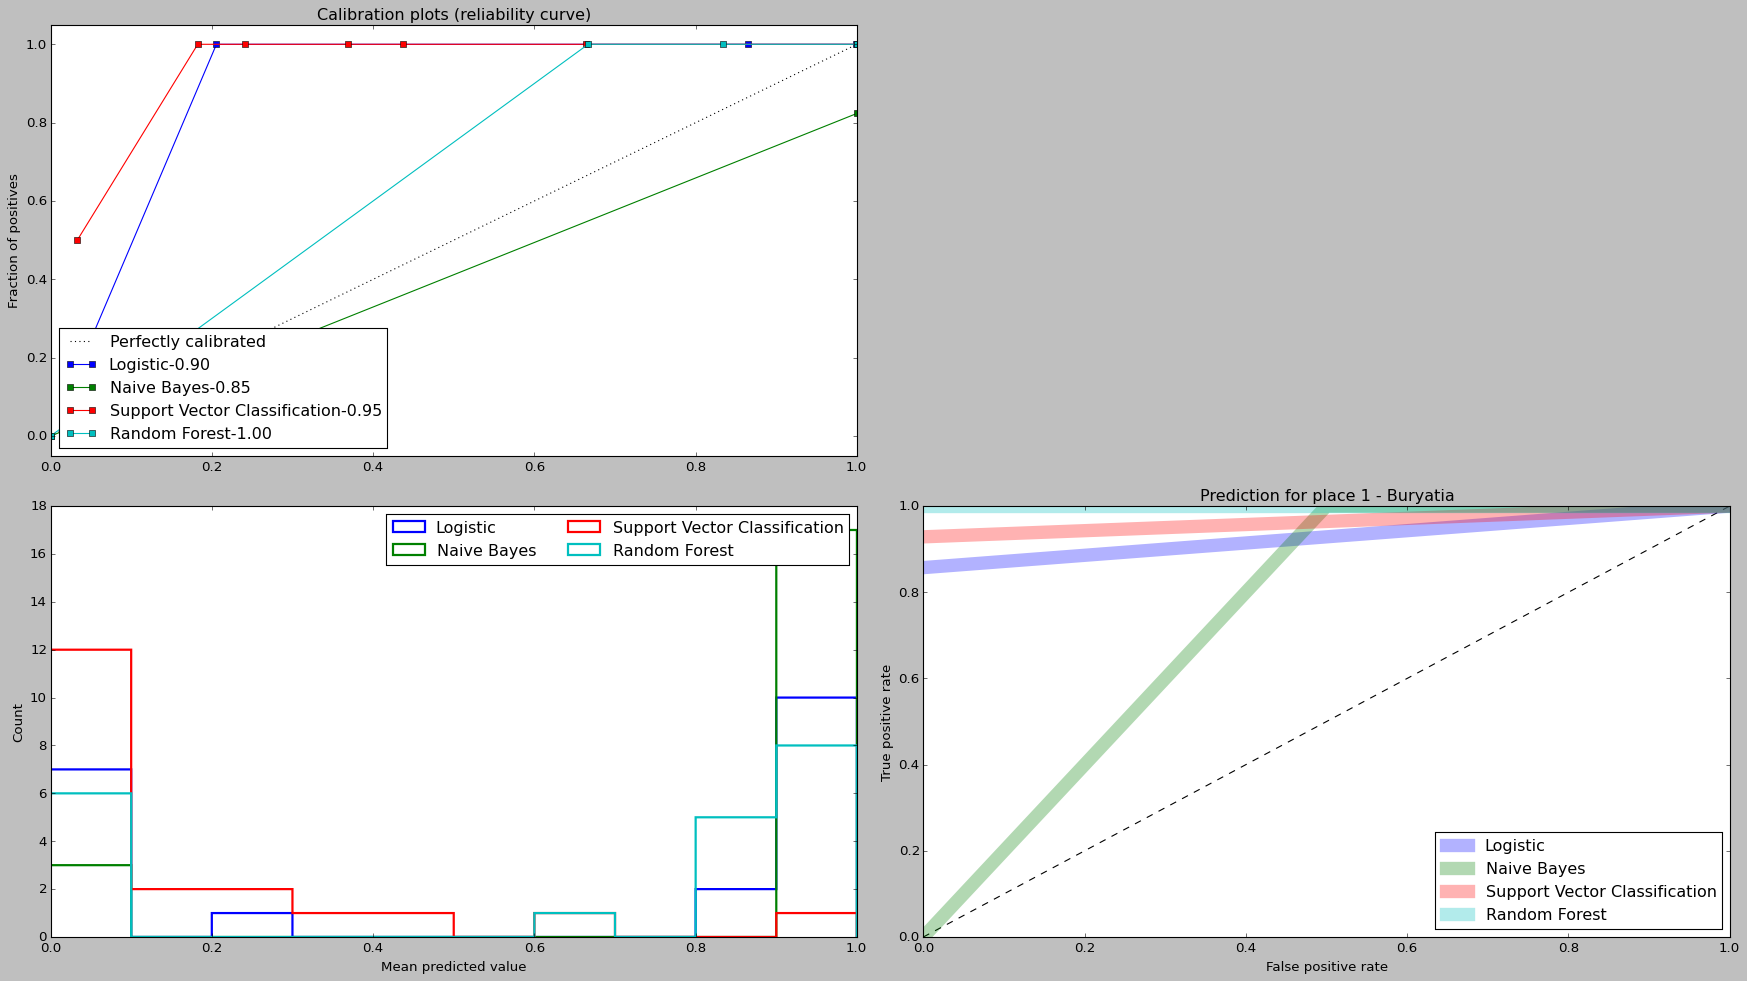

In [196]:
import numpy as np
np.random.seed(0)

import matplotlib.pyplot as plt

from sklearn import datasets
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import calibration_curve
from sklearn import metrics

from sklearn.tree import export_graphviz
import pydot

from sklearn.metrics import roc_curve

def data(fname):
    with open(fname) as f:
        from csv import reader
        rf = reader(f)
        train = []
        y = []
        for i,row in enumerate(rf):
            ##if i == 0:
            ##    continue
            train_row= [float(r) for r in row[1:]]
            ##print row
            train += [train_row,]
            y += [float(row[0]),]
    return y, train

y,train = data('train.csv')

# Create classifiers
lr = LogisticRegression(solver='lbfgs')
gnb = GaussianNB()
svc = LinearSVC(C=1.0)
rfc = RandomForestClassifier(n_estimators=6)


plt.figure(figsize=(22, 18))
##ax1 = plt.subplot2grid((3, 1), (0, 0), rowspan=2)
ax1 = plt.subplot2grid((3, 2), (0, 0))
ax2 = plt.subplot2grid((3, 2), (1, 0))
##ax3 = plt.subplot2grid((3, 2), (0, 1))
ax4 = plt.subplot2grid((3, 2), (1, 1))

ax1.plot([0, 1], [0, 1], "k:", label="Perfectly calibrated")
rf = None
y_pred_rf = None
rocs = []
X_train = train
y_train = y
X_test = np.array(train[-20:])
y_test = np.array(y[-20:])
for clf, name in [
        (lr, 'Logistic'),
                  (gnb, 'Naive Bayes'),
                  (svc, 'Support Vector Classification'),
                  (rfc, 'Random Forest')]:
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    fpr, tpr, _ = roc_curve(y_test, y_pred)
    ##raise Exception((y_test, y_pred))
    rocs += [(fpr, tpr, name),]
    ##raise Exception(rocs)

    if name == 'Random Forest':
        y_pred_rf = y_pred
        errors = np.abs(y_pred_rf - y_test)
        print('rf Mean Absolute Error:', round(np.mean(errors), 2),
                'Prob(hail).')
        # Calculate mean absolute percentage error (MAPE)
        mse = metrics.mean_squared_error(y_test, y_pred_rf)
        print 'rf mse:', mse
        ##raise Exception('stop')
        if 0:
            mape = 100 * (errors / y_test)
            # Calculate and display accuracy
            accuracy = 100 - np.mean(mape)
            print('Accuracy:', round(accuracy, 2), '%.')
        if 1:
            feature_list = [c[0] for c in common]
        print 'len(clf.estimators_) = ', len(clf.estimators_)
        for i,clf_estimator in enumerate(clf.estimators_):
            tree = clf_estimator
            # Export the image to a dot file
            export_graphviz(tree, out_file = 'tree_%d.dot' % i, feature_names = feature_list, rounded = True, precision = 1)
            # Use dot file to create a graph
            if 1:
                import pygraphviz as pgv
                G = pgv.AGraph("tree_%d.dot" % i)
                G.draw('rf_out_%d.png' % i,prog='dot')
            if 0:
                (graph, ) = pydot.graph_from_dot_file('tree.dot')
                # Write graph to a png file
                graph.write_png('tree.png')
    score = clf.score(X_test, y_test)
    if hasattr(clf, "predict_proba"):
        prob_pos = clf.predict_proba(X_test)[:, 1]
    else:  # use decision function
        prob_pos = clf.decision_function(X_test)
        prob_pos = \
            (prob_pos - prob_pos.min()) / (prob_pos.max() - prob_pos.min())
    fraction_of_positives, mean_predicted_value = \
        calibration_curve(y_test, prob_pos, n_bins=10)

    ax1.plot(mean_predicted_value, fraction_of_positives, "s-",
             label="%s-%.2f" % (name, score))

    ax2.hist(prob_pos, range=(0, 1), bins=10, label=name,
             histtype="step", lw=2)

ax1.set_ylabel("Fraction of positives")
ax1.set_ylim([-0.05, 1.05])
ax1.legend(loc="lower left")
ax1.set_title('Calibration plots (reliability curve)')

if 1:
    ax2.set_xlabel("Mean predicted value")
    ax2.set_ylabel("Count")
    ax2.legend(loc="best", ncol=2)

if 0:
    w = np.where(y_test != y_pred_rf)
    n_error = w[0].shape[0]+0.
    pct_error = n_error/y_test.shape[0]

    ax3.plot(y_test, y_pred_rf, 'b.', linewidth=3, alpha=0.01)
    ax3.set_xlabel('truth')
    ax3.set_ylabel('P(hail), test_error = %.3f (%d/%d)' % (pct_error, n_error, y_test.shape[0]))

##raise Exception(pct_error)
##raise Exception((y_test, y_pred_rf))
##plt.figure(1)
ax4.plot([0, 1], [0, 1], 'k--')
##ax4.plot(fpr_rt_lm, tpr_rt_lm, label='RT + LR')
for x,y,name in rocs:
    ##ax4.plot(fpr_rf, tpr_rf, label='RF')
    ax4.plot(x, y, label=name, alpha=0.3, linewidth=12)
    ##raise Exception((x,y))
##ax4.plot(fpr_rf_lm, tpr_rf_lm, label='RF + LR')
##plt.plot(fpr_grd, tpr_grd, label='GBT')
##plt.plot(fpr_grd_lm, tpr_grd_lm, label='GBT + LR')
ax4.set_xlabel('False positive rate')
ax4.set_ylabel('True positive rate')
ax4.set_title('ROC curve')
ax4.legend(loc='best')
plt.title('Prediction for place %d - %s' % (ix,common[ix][0]))
##plt.show()

plt.tight_layout()
plt.show()



In [177]:
rocs

[(array([0., 1.]), array([0., 1.]), 'Logistic'),
 (array([0., 1.]), array([0.84210526, 1.        ]), 'Naive Bayes'),
 (array([0., 1.]), array([0., 1.]), 'Support Vector Classification'),
 (array([0., 1.]), array([1., 1.]), 'Random Forest')]

In [ ]:
pd.Timestamp('2019-06-30 20:12:00').date()

In [ ]:
df_target = df[russia_locations_with_country]
len(df_target)

In [20]:
# combine the tweets for the entire sample and extract common verbs measured by backlinks
from util import TextRank4Keyword
import util as utilp
reload(utilp)

<module 'util' from 'util.pyc'>

In [25]:
# first two weeks of July
mask = (df_target['date'] > '2019-6-20') & (df_target['date'] <= '2019-7-15')
dft_7_1_2 = df_target[mask]
text = '\n'.join([unicode(d,encoding='latin-1') for d in dft_7_1_2['english']]) ## df['english]

In [92]:
# plot lat,lon on map
xx = df_target[(df_target['lat'] != 0.) & (df_target['lon'] != 0.)][['lat','lon']]

In [ ]:
import pandas as pd
import geopandas
import matplotlib.pyplot as plt

In [100]:
len(xx['lat'])

2327

In [97]:
gdf = geopandas.GeoDataFrame(
    df, geometry=geopandas.points_from_xy(xx['lon'].tolist(), xx['lat'].tolist()))

ValueError: Length of values does not match length of index

In [107]:
##nlp = spacy.load("en_core_web_lg", disable=['ner', 'textcat'])

In [29]:
# For the text sample, extract verbs in english
tr4w = utilp.TextRank4Keyword()
tr4w.analyze(text,
        candidate = {'pos':['VERB']},
             window_size=4,
             lower=False,  ## convert to lowercase
            stop=True,  ## remove stop words (and, or but is that, etc.)  set to False if scanning for prepositions
            )
x = tr4w.get_keywords(10)
## protesting, continue, going, vote

expressed - 9.463698394053484
http - 6.928534410483576
protest - 5.947695742694544
protested - 5.823196690259035
want - 3.264621325060267
said - 3.1868177200519874
going - 2.4295537165639676
need - 2.3432715277777776
come - 2.2610678092061116
's - 2.169757407407407
gathered - 2.110584683147874
organized - 2.0359453099051987


In [30]:
# For the text sample, extract gerunds
tr4w.analyze(text,
        candidate = {'tag':['VBG',]},
             window_size=4,
             lower=False,
            stop=True)
x = tr4w.get_keywords(10)
# protesting, looting, taking, going, stealing, burning

reasoning - 1.0
living - 1.0
daring - 1.0
going - 1.0
watching - 1.0
imitating - 1.0
building - 1.0
rebelling - 1.0
protesting - 1.0
leaving - 1.0
saying - 0.15000000000000002
Miting - 0.15000000000000002


In [73]:
len(df_target)

3508

In [75]:
# identify nouns and proper nouns
##mask = (df_target['date'] > '2019-6-20') & (df_target['date'] <= '2019-7-7')
mask = (df['date'] > '2019-8-28') & (df['date'] <= '2019-9-05')
dft = df_target[mask]
text = '\n'.join([unicode(d,encoding='latin-1') for d in dft['english']]) ## df['english]


tr4w.analyze(text,
        candidate = {'pos':['NOUN','PNOUN']},
             ##{'pos':['IN',]}, ## nothing
             window_size=4,
             lower=False,
            stop=True)
x = tr4w.get_keywords(10)

/opt/local/Library/Frameworks/Python.framework/Versions/2.7/lib/python2.7/site-packages/ipykernel_launcher.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  after removing the cwd from sys.path.


protest - 41.045308772344065
https - 14.903217694313595
people - 7.440185508109832
protests - 5.746463973069463
elections - 4.150674115456346
power - 3.782383418256401
% - 3.7823071109877313
today - 3.708904478278702
election - 3.5359310735949454
time - 3.450797549734767
opposition - 3.431444297505783
city - 3.329149275337183


In [77]:
# identify nouns and proper nouns
##mask = (df_target['date'] > '2019-6-20') & (df_target['date'] <= '2019-7-7')
mask = (df_target['date'] > '2019-8-28') & (df_target['date'] <= '2019-9-05')
dft_7_1_2 = df_target[mask]
print len(dft_7_1_2)
text = '\n'.join([unicode(d,encoding='latin-1') for d in dft_7_1_2['english']]) ## df['english]


tr4w.analyze(text,
        candidate = {'pos':['NOUN','PNOUN']},
             ##{'pos':['IN',]}, ## nothing
             window_size=4,
             lower=False,
            stop=True)
x = tr4w.get_keywords(10)
# people, gasoline, government, streets, increase, gas
# 7-1-2015 to 7-15-2015
"""
------ 7 1/4
designation - 4.247308073868852
territory - 3.799327409831307
summit - 3.6074092441070644
people - 3.5578823163893056
connection - 2.7882506287204905
materials - 2.4361246731737576
fact - 2.2214761894674133
------ 7 2/4
people - 7.263455710540336
candidates - 5.426098584608043
liberation - 5.018246469861076
opposition - 4.64018781276433
elections - 3.6076127664414837
government - 3.3806112241230433
honor - 3.143002492928491
country - 3.1277204553548588
====== 7 3/4
opposition - 5.324676681463514
people - 4.763127063367123
rally - 3.8577767546677486
authorities - 3.318476872972944
power - 2.9740300106320863
election - 2.8847805111274942
region - 2.705223747552415
candidates - 2.6537366741992625
elections - 2.3508393837754618
====== 7 4/4
people - 18.13336171592063
police - 9.32819914452686
opposition - 8.190278274664276
rally - 6.413734362059225
elections - 6.055858499892071
power - 5.524221180614851
authorities - 4.947946352777613
====== 8 1/4
people - 16.82001750091844
elections - 8.01539760993783
protests - 7.930761535676105
power - 7.382014040071608
police - 6.791075796011313
country - 6.153882271333403
rally - 5.2651490243619214
authorities - 4.88525421912398
===== 8 2/4
people - 19.07523354458062
rally - 10.159579035325132
country - 7.4316228572596925
police - 7.310084938707491
elections - 7.092275452258131
authorities - 5.985499364764716
power - 5.879978095910845
opposition - 5.560931809440686

=======8 3/4
people - 15.425246927312688
power - 5.14567530858174
elections - 4.90110215638186
police - 4.549506670142022
authorities - 4.470625592895112
rally - 4.371051679815987
election - 4.251371075415529
opposition - 4.18273801053843
=======8 4/4
people - 5.838770232800393
power - 4.613030679409684
years - 3.478302912095094
doctors - 3.076012685323993
elections - 2.995852157028364
authorities - 2.6033726696857746
time - 2.5249132122120829
=======9 1/4
people - 9.06553466858036
*elections - 4.035964571824621
*election - 4.029761516784266
time - 3.895898464284005
city - 3.8172191049011843
power - 3.685547721154452
today - 3.667441883433381
=======9 2/4
people - 8.65056108433791
elections - 5.863929335589142
opposition - 5.537889925108563
administration - 3.936077673454713
police - 3.869997647977744
election - 3.282191033117138
time - 3.2369688595014003
capital - 3.089540277440597
power - 3.019373499326754

# 9 1/4 has both elections and election as top terms, indicating high likelihood of election/elections keywords
during that period.

Q: does any specific period of election/election have a location-specific area?
"""

278
protest - 41.045308772344065
https - 14.903217694313595
people - 7.440185508109832
protests - 5.746463973069463
elections - 4.150674115456346
power - 3.782383418256401
% - 3.7823071109877313
today - 3.708904478278702
election - 3.5359310735949454
time - 3.450797549734767
opposition - 3.431444297505783
city - 3.329149275337183


'\n------ 7 1/4\ndesignation - 4.247308073868852\nterritory - 3.799327409831307\nsummit - 3.6074092441070644\npeople - 3.5578823163893056\nconnection - 2.7882506287204905\nmaterials - 2.4361246731737576\nfact - 2.2214761894674133\n------ 7 2/4\npeople - 7.263455710540336\ncandidates - 5.426098584608043\nliberation - 5.018246469861076\nopposition - 4.64018781276433\nelections - 3.6076127664414837\ngovernment - 3.3806112241230433\nhonor - 3.143002492928491\ncountry - 3.1277204553548588\n====== 7 3/4\nopposition - 5.324676681463514\npeople - 4.763127063367123\nrally - 3.8577767546677486\nauthorities - 3.318476872972944\npower - 2.9740300106320863\nelection - 2.8847805111274942\nregion - 2.705223747552415\ncandidates - 2.6537366741992625\nelections - 2.3508393837754618\n====== 7 4/4\npeople - 18.13336171592063\npolice - 9.32819914452686\nopposition - 8.190278274664276\nrally - 6.413734362059225\nelections - 6.055858499892071\npower - 5.524221180614851\nauthorities - 4.947946352777613\n====

In [82]:
print dft_7_1_2[dft_7_1_2['english'].str.contains("election")]["english"]

4491    Nonsense do not write. It Navalny again manage...
4494    Moscow City Duma elections can not be separate...
4690    Just to explain why the wave of protests even ...
4763    You might have forgotten that the Moscow City ...
5159    Sobchak go. Navalny calls not to go to the pre...
5289    People remember the accounts are written befor...
5455    Thousands of people participated in a protest ...
5466    _ @Tvrain _ @dw_russian _ @SobolLubov _ Moscow...
5493    Thousands of people participated in a protest ...
5610    Moscow hosts the uncoordinated action of "free...
5662    I remind you that in Moscow today at 14:00 wil...
5784    Telegram old square (the staff of the Russian ...
5847    Kirill Rogov: The right to peaceful protest is...
5865    # News Protest affect the election: August 30,...
5866    FREE RUSSIAN NEW ON SITE: Protest affect the e...
6235    So Bulk offers support Lenya Zyuganov! What's ...
6278    # Omsk300 #Roubel Just boycott will not help, ...
Name: english,

ValueError: No axis named english for object type <class 'pandas.core.frame.DataFrame'>

In [19]:
# combine the tweets for the entire sample and extract common verbs measured by backlinks
from util import TextRank4Keyword
russian = '\n'.join([unicode(d,encoding='latin-1') for d in df['text']])

In [20]:
import codecs

with codecs.open('russian.txt','w', encoding='utf-8') as f:
    f.write(russian)

In [21]:
tr4w = TextRank4Keyword()
tr4w.analyze(russian,
        candidate = {'pos':['NOUN','PNOUN']},
             ##{'pos':['IN',]}, ## nothing
             window_size=4,
             lower=False,
            stop=True)
x = tr4w.get_keywords(10)
# people, gasoline, government, streets, increase, gas

° - 45.23148405284614
https:// - 33.68018465928698
march - 19.002652632020578
memory - 17.52398003410248
opposition - 15.297998730486889
boris - 13.602465566248332
http:// - 11.305461915582935
leader - 11.285432682736229
opositor - 10.751071794940422
# - 9.153394682576273
people - 9.098377204017662
por - 8.01032252794822


In [5]:
x

[]